# Очистка и проверка данных таблицы rental

In [1]:
import os
import sys

# Указание Директории
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Добавление корня проекта в sys.path (cwd уже переключён на корень)
sys.path.append(os.getcwd())
from src.boxplotting import plot_price_boxplot
from src.segmentation import (
    add_premium_flag,
    add_premium_flag_by_year,
    compare_premium_methods,
    add_new_moscow_flag,
    compare_old_vs_new_moscow_median,
    plot_old_vs_new_moscow_boxplot,
    plot_new_moscow_share_pie,
)

print(f"Текущая директория: {os.getcwd()}")

Текущая директория: D:\Moscow_rent_analysis


Проверка и очистка пустых ячеек

In [2]:
import pandas as pd
from pathlib import Path

os.makedirs('data/processed', exist_ok=True)
PROJECT_ROOT = Path(os.getcwd())
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

df_raw_rentals = pd.read_csv(RAW_DIR / 'rentals.csv')

# Проверка данных
print(f"Проверка данных")
print(f"Строк: {len(df_raw_rentals)}")
print(f"Столбцов: {len(df_raw_rentals.columns)}")
print(f"Пустых значений: {df_raw_rentals.isnull().sum().sum()}")

# Приведение к формату и очистка
df_clean_rentals = df_raw_rentals.copy()
df_clean_rentals['building_year'] = df_clean_rentals['building_year'].astype(int)
df_clean_rentals['date_posted'] = pd.to_datetime(df_clean_rentals['date_posted'])

#Проверка после очистки
print("\nПосле очистки:")
print(f"Строк: {len(df_clean_rentals)}")

Проверка данных
Строк: 20000
Столбцов: 22
Пустых значений: 0

После очистки:
Строк: 20000


Проверка выбросов

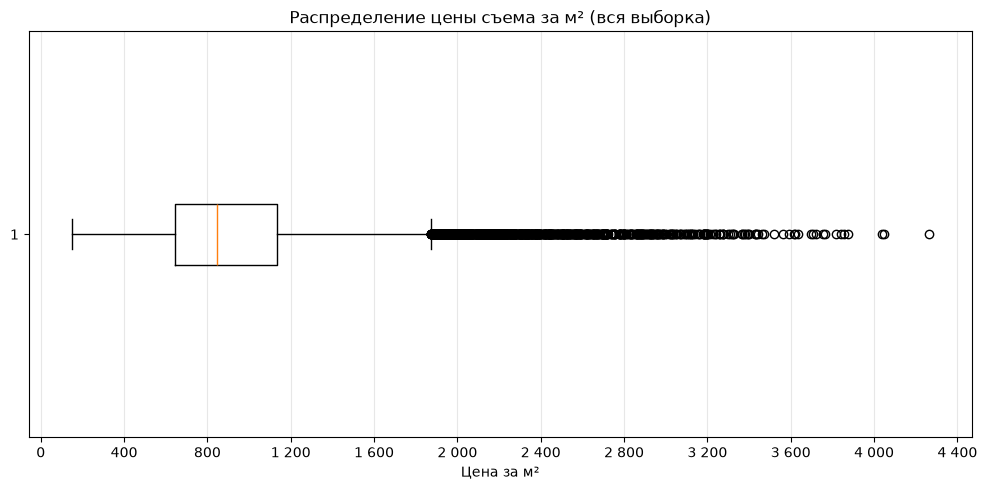

In [3]:
plot_price_boxplot(
    df_clean_rentals['rent_per_sqm'],
    'Распределение цены съема за м² (вся выборка)',
    delenia=12,
    width=10.0,
    height=5.0
)

Проверка выбросов с правой стороны графика

In [4]:
df_clean_rentals.nlargest(15, 'rent_per_sqm')[['id', 'rent_per_sqm', 'okrug', 'total_area', 'to_center_km', 'monthly_rent_rub']]

,id,rent_per_sqm,okrug,total_area,to_center_km,monthly_rent_rub
11611,R011612,4264,CAO,39.5,3.28,168400
10882,R010883,4048,CAO,69.9,3.69,282900
11955,R011956,4036,CAO,46.9,3.03,189300
17788,R017789,3877,CAO,44.4,5.79,172200
10204,R010205,3855,CAO,43.5,3.53,167700
14148,R014149,3840,CAO,67.1,4.38,257600
8879,R008880,3815,CAO,63.6,2.37,242600
3392,R003393,3766,CAO,58.6,1.88,220700
7176,R007177,3754,CAO,57.1,5.18,214300
18139,R018140,3722,CAO,40.8,4.79,151800


Выбросы не были обнаружены, исходя по минимальной отдаленности от центра и ЦАО -> правые значения графика - это премиум-сегмент съема жилья

## Выделение премиум-сегмента

Разделим на 2 группы жилье: обычный сегмент и премиум-сегмент методом квартильного размаха

### Исправление методики: порог считается внутри года

**Здесь была методологическая ошибка, и ниже она разобрана, а не спрятана.**

Изначально порог премиум-сегмента считался один на всю таблицу: Q3 + 1.5 × IQR по всем объявлениям 2020-2026 годов сразу. Выглядело безобидно, но в разделе 8.5.2 глубокого анализа проверка показала, что это неверно.

Цены за период выросли, а порог зафиксирован на среднем уровне всего шестилетия. Из-за этого объявлению 2020 года нужно быть гораздо более выдающимся, чтобы получить метку премиума, чем объявлению 2026 года. Другими словами, `is_premium` частично кодировал не «дорогое жильё», а **«объявление размещено позже»**.

Правильный порог — свой для каждого года. Тогда премиум означает «дорогое относительно своего времени».

Ниже оба расчёта подряд: сначала старый, как было, потом новый, как стало, и сравнение.

**Шаг 1. Как было** — один порог на все годы (`add_premium_flag`). Функция намеренно оставлена в `src/segmentation.py`, чтобы ошибку можно было воспроизвести.

In [5]:
df_clean_rentals = add_premium_flag(df_clean_rentals, 'rent_per_sqm')

Q1 = 644
Q3 = 1135
IQR = 491
Порог премиум-сегмента: 1872
is_premium
False    18999
True      1001
Name: count, dtype: int64

Доля премиум-сегмента: 5.0%


**Шаг 2. Как стало** — порог внутри каждого года (`add_premium_flag_by_year`). Эта строка перезаписывает `is_premium`, и дальше по ноутбуку и во всём проекте используется уже она.

In [6]:
df_clean_rentals = add_premium_flag_by_year(df_clean_rentals, 'rent_per_sqm')

      Объявлений  Порог года  Премиум, шт  Премиум, %
Год                                                  
2021        3788      1622.0          201         5.3
2022        3869      1734.0          200         5.2
2023        3797      1901.0          189         5.0
2024        3705      1978.0          208         5.6
2025        3643      1969.0          168         4.6
2026        1198      1997.0           62         5.2

Всего премиум-сегмента: 1028 (5.1%)


**Шаг 3. Что изменилось** — сравнение двух методов по годам.

In [7]:
premium_methods = compare_premium_methods(df_clean_rentals, 'rent_per_sqm')
print()
print(premium_methods.to_string())

Общий порог по всей выборке: 1 872
Премиум по общему порогу:  1001 (5.0%)
Премиум по порогу года:    1028 (5.1%)

Сменили метку: 243 объявлений из 20000 (1.2%)
  были премиумом, перестали: 108
  не были премиумом, стали:  135

      Объявлений  Порог года  Премиум по общему порогу, %  Премиум по порогу года, %  Сменили метку, шт
Год                                                                                                    
2021        3788      1622.0                          3.0                        5.3                 89
2022        3869      1734.0                          4.0                        5.2                 46
2023        3797      1901.0                          5.4                        5.0                 15
2024        3705      1978.0                          6.8                        5.6                 45
2025        3643      1969.0                          5.6                        4.6                 35
2026        1198      1997.0                 

### Что дало исправление (аренда)

Общий порог — 1 872 руб/м² на все годы. Порог, посчитанный внутри года, растёт вместе с рынком: с 1 622 в 2021 году до 1 997 в 2026, то есть **на +23%**.

Последствие видно в таблице: по старому методу доля премиума ползла с 3.0% в 2021 до 6.8% в 2024 — рынок дорожал, и всё больше обычных квартир перешагивало неподвижную планку. По новому методу доля держится в коридоре 4.6-5.6% и никуда не едет.

Общее число премиум-объявлений почти не изменилось (1 001 против 1 028), но **243 объявления сменили метку**: 108 перестали быть премиумом, 135 стали. Это 1.2% таблицы — немного, но это ровно те объекты, на которых старый метод путал «дорогое» и «свежее».

Построим для наглядности график-боксплот, исключающий премиум-сегмент квартиры

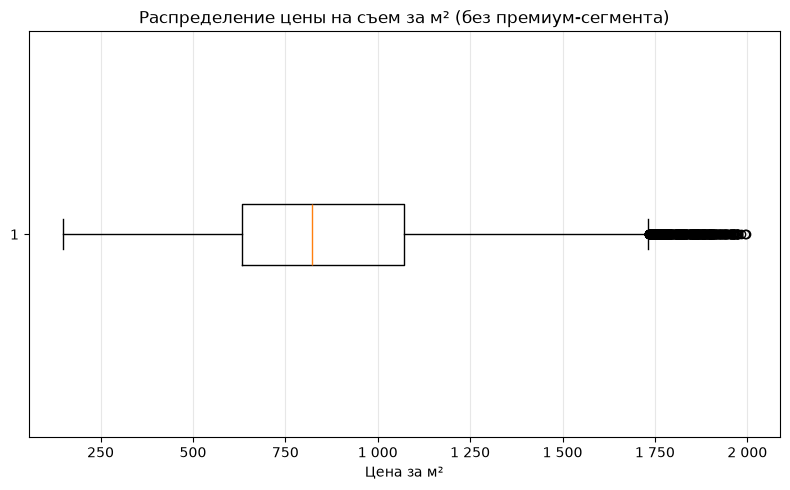

In [8]:
df_no_premium = df_clean_rentals[~df_clean_rentals['is_premium']]
plot_price_boxplot(
    df_no_premium['rent_per_sqm'],
    'Распределение цены на съем за м² (без премиум-сегмента)',
    delenia=10,
    width=8.0,
    height=5.0
)

Заметим, что на первый взгляд в таблицах также есть несоответствие в колонке to_center_km слишком большие значения, вплоть до 600-700 км. Это присоединенная ранее или в течение периода "Новая Москва" в виде трех округов: "TAO", "NAO", "ZelAO"

## Выделение Новой Москвы

Разделим данные, аналогично с колонкой "is_premium"

In [9]:
df_clean_rentals = add_new_moscow_flag(df_clean_rentals)

is_new_moscow
False    16591
True      3409
Name: count, dtype: int64
Доля Новой Москвы: 17.0%


In [10]:
df_clean_rentals[df_clean_rentals['is_new_moscow']]['is_premium'].value_counts()

is_premium
False    3409
Name: count, dtype: int64

Ни один объект Новой Москвы не попал в премиум-сегмент (0 из 3409). Это количественно доказывает, что Новая Москва - принципиально иной, более доступный сегмент рынка, а не часть единого "московского" распределения цен.

Важно: порог премиум-сегмента (IQR) считается внутри каждого года по всей выборке этого года, включая Новую Москву, а не отдельно по Старой Москве. Это не искажает результат: Новая Москва - компактный кластер низких цен, полностью лежащий ниже Q1 и Q3, и не образует собственных выбросов сверху. Она не может "перетянуть" границу премиум-сегмента, поэтому отдельный пересчёт порога по Старой Москве не требуется.

## Визуализация разницы Новой и Старой Москвы

In [11]:
compare_old_vs_new_moscow_median(df_clean_rentals, 'rent_per_sqm')

Старая Москва, медиана rent_per_sqm: 922
Новая Москва, медиана rent_per_sqm: 418
Разница: в 2.2 раз


## Бокс-плот

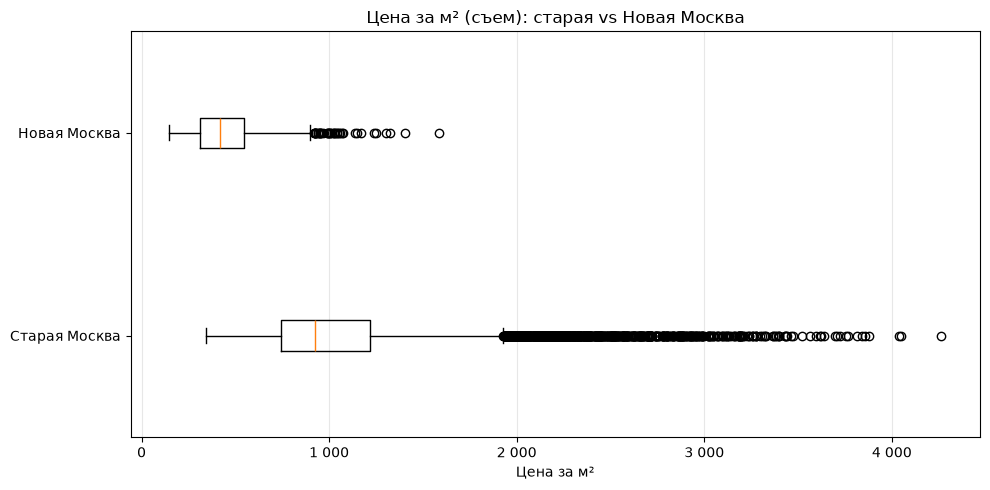

In [12]:
plot_old_vs_new_moscow_boxplot(df_clean_rentals, 'rent_per_sqm', 'съем')

Сделаем вывод, что рынок Старой Москвы более разнороден - есть как бюджетные варианты, так и элитное жилье. Новая Москва более однородна по ценам.

## Круговая диаграмма

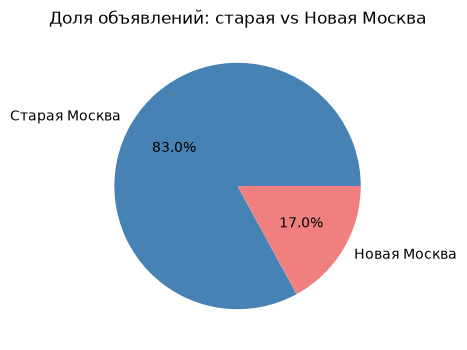

In [13]:
plot_new_moscow_share_pie(df_clean_rentals)

Сохраним новые данные в измененную таблицу processed

In [14]:
df_clean_rentals.to_csv('data/processed/clean_rentals.csv', index=False)